In [1]:
import pandas as pd

In [2]:
columns_headers = [
    "time", "gender", "highschool_grade", "study_year","faculty","ung_grade_2023","accomodation","allowance","scholarship","study_hours",
    "party_week","drinks_night","missed_classes", "failed_classes", "in_relationship","parent_approve","relation_parent"
]
student_df = pd.read_csv("student_survey.csv", names=columns_headers, header=0)

In [3]:
student_df.drop("time", axis = 1, inplace= True)

In [4]:
student_df.head()

,gender,highschool_grade,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


## Data Manipulation / Cleaning / Transfomring / Processing

* Unwanted columns removal
* Duplicated value removal
* Null value Handling
* outlier Handling
* Feature Engineering
* Encoding
* Normalization (Post -processing)

In [5]:
student_df.shape

(406, 16)

In [6]:
# Removing Duplicated Rows
student_df.drop_duplicates(inplace = True)

In [7]:
student_df.shape

(403, 16)

In [8]:
# Counting Null Values
student_df.isna().sum()

gender               1
highschool_grade     6
study_year          71
faculty              6
ung_grade_2023      84
accomodation        22
allowance           30
scholarship          7
study_hours          2
party_week           1
drinks_night         1
missed_classes       2
failed_classes       2
in_relationship      2
parent_approve       3
relation_parent      2
dtype: int64

In [9]:
# Removing Rows with 60% / 9 null values
student_df.dropna(axis = 0, thresh = 6, inplace= True)

In [10]:
student_df.isna().sum()

gender               0
highschool_grade     5
study_year          70
faculty              5
ung_grade_2023      83
accomodation        21
allowance           29
scholarship          6
study_hours          1
party_week           0
drinks_night         0
missed_classes       1
failed_classes       1
in_relationship      1
parent_approve       2
relation_parent      1
dtype: int64

In [11]:
## Domain Expert -> Remove null values on column "study_year"
domain_expert_df = student_df.dropna(subset="study_year")

print(domain_expert_df.shape)

(332, 16)


In [12]:
domain_expert_df.dropna(subset="ung_grade_2023", inplace = True)

domain_expert_df.isna().sum()

gender               0
highschool_grade     2
study_year           0
faculty              3
ung_grade_2023       0
accomodation         1
allowance           14
scholarship          0
study_hours          0
party_week           0
drinks_night         0
missed_classes       1
failed_classes       0
in_relationship      1
parent_approve       1
relation_parent      1
dtype: int64

In [13]:
## Self Understanding -> Lets use Highschool as filler for "study_year" and theit corresponding
## highschool grade as last yers grade or filler for "ung_grade_2023"
study_year_null_mask = student_df.study_year.isna()

self_explained_df = student_df.copy()
self_explained_df.study_year = student_df.study_year.fillna("Highschool")

self_explained_df.loc[study_year_null_mask, "ung_grade_2023"] = self_explained_df.loc[study_year_null_mask, "highschool_grade"]

In [14]:
self_explained_df.dropna(subset="ung_grade_2023", inplace = True)

self_explained_df.isna().sum()

gender               0
highschool_grade     2
study_year           0
faculty              4
ung_grade_2023       0
accomodation        19
allowance           27
scholarship          6
study_hours          0
party_week           0
drinks_night         0
missed_classes       1
failed_classes       1
in_relationship      1
parent_approve       1
relation_parent      1
dtype: int64

In [15]:
## Remove Null Values or Imputation (Mode)
## Fill categorigal values with mode
impute_with_mode = ["faculty", "missed_classes", "failed_classes", "in_relationship", "parent_approve", "relation_parent"]

for column in impute_with_mode:
    self_explained_df[column] = self_explained_df[column].fillna(
        self_explained_df[column].mode()[0]
    )

self_explained_df["highschool_grade"] = self_explained_df["highschool_grade"].fillna(
        self_explained_df["highschool_grade"].median()
)

# Alternatively :
# mode_dict = self_explained_df[impute_with_mode].mode().iloc[0].to_dict()
# self_explained_df.fillna(value=mode_dict, inplace=True)

In [16]:
## Null as Feature

self_explained_df.fillna(value="Unknown", inplace= True)

,gender,highschool_grade,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,Male,85.0,Highschool,Arts & Social Sciences,85.0,Unknown,R 5001 - R 6000,No,3-5,Only weekends,3-5,0,0,No,Yes,Very close
401,Female,74.0,Highschool,Science,74.0,Private accommodation/ stay with family/friends,Unknown,No,3-5,3,1-3,0,0,No,Yes,Close
402,Female,73.0,2nd Year,Economic & Management Sciences,58.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,"Yes (NSFAS, etc...)",5-8,1,8+,0,0,Yes,Yes,Very close
404,Male,85.0,Highschool,Economic & Management Sciences,85.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,1-3,4+,5-8,4+,0,No,Yes,Close


In [17]:
self_explained_df.shape

(386, 16)

In [18]:
self_explained_df.isna().sum()

gender              0
highschool_grade    0
study_year          0
faculty             0
ung_grade_2023      0
accomodation        0
allowance           0
scholarship         0
study_hours         0
party_week          0
drinks_night        0
missed_classes      0
failed_classes      0
in_relationship     0
parent_approve      0
relation_parent     0
dtype: int64

In [19]:
# Correlation 
self_explained_df.corr(numeric_only=True)

,highschool_grade,ung_grade_2023
highschool_grade,1.000000,0.388055
ung_grade_2023,0.388055,1.000000


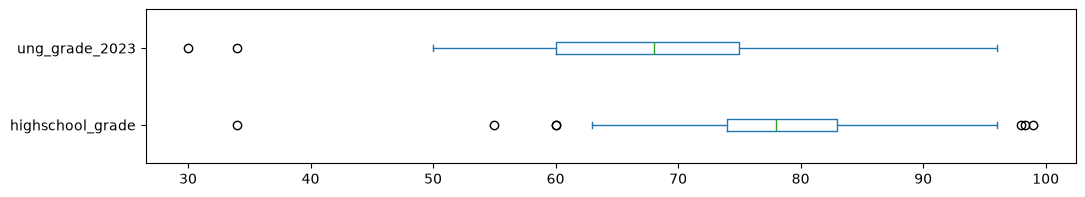

In [20]:
# Outlier Handling
self_explained_df[["highschool_grade","ung_grade_2023"]].plot(kind = "box", figsize = (12, 2), vert = False)

def handle_outlier(series : pd.Series):
    """ Handling Outlier using IQR. """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    
    IQR = Q3 - Q1
    min_value = Q1 - (1.5 * IQR)
    max_value = Q3 + (1.5 * IQR)

    outliers = series[(series > max_value) | (series < min_value)]
    print(outliers)
    
    return self_explained_df.drop(outliers.index, axis = 0)

In [21]:
self_explained_df = self_explained_df.highschool_grade.aggregate(handle_outlier)
self_explained_df = self_explained_df.ung_grade_2023.aggregate(handle_outlier)

38     99.00
54     98.00
73     98.33
254    34.00
268    60.00
335    55.00
358    60.00
Name: highschool_grade, dtype: float64
303    30.0
Name: ung_grade_2023, dtype: float64


In [22]:
self_explained_df.shape

(378, 16)

In [23]:
self_explained_df.head()

,gender,highschool_grade,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


In [25]:
## Saving Cleaned Daaset

self_explained_df.to_csv("student_survey_clean.csv", index = False)